# 🏦 Retención Bancaria: Segmentación Conductual y Predicción Asimétrica de Churn

### 📊 Resumen Ejecutivo: Sistema de Decisiones *Cost-Sensitive* para Churn de Tarjetas de Crédito

* **Contexto:** En banca de tarjetas de crédito, la fuga de clientes (*churn*) erosiona directamente el margen financiero. Pero no todos los clientes valen lo mismo ni cuesta lo mismo retenerlos: alertar a un *Súper Usuario* implica una llamada humana costosa, mientras que rescatar a un cliente desconectado cuesta apenas un correo automático. Este proyecto construye un **pipeline de producción** (`main.py` + módulos en `src/`) que segmenta la cartera, predice el churn y **decide a quién contactar maximizando el beneficio neto esperado**, no la métrica estadística.

* **Objetivo Estratégico:** Pasar de un modelo "que predice bien" a un **motor de decisiones que gana dinero**, integrando tres piezas: 
    1) Segmentación conductual no supervisada
    2) Clasificación supervisada de churn
    3) Un motor de umbrales asimétricos calibrado sobre la *unit economics* real de cada segmento.

* **Dataset:** `BankChurners.csv` (Kaggle — *Credit Card Customers*). **10,127 clientes**, 21 variables conductuales/demográficas y una tasa base de churn del **~16%** (problema desbalanceado).

* **Metodología y Flujo de Trabajo (espejo de `src/`):**
    1. 🧹 **Carga y blindaje anti-leakage** (`data_processing.py`): descarte de la *trampa de Kaggle* (columnas Naive Bayes) y partición estratificada en **tres vías** (60/20/20).
    2. 🧭 **Segmentación conductual** (`clustering_models.py`): `K-Means` (K=4) ajustado solo en *train*, con **relabeling canónico por arquetipo** para estabilidad de producción.
    3. 🤖 **Clasificación de churn** (`classification_models.py`): `LightGBM` con manejo nativo de categóricas, interpretado con *Feature Importance* y `SHAP`.
    4. 💰 **Motor de decisiones asimétrico** (`decision_engine.py`): umbrales *cost-sensitive* por clúster, calibrados en **validación** y evaluados sobre un *test* intacto.
    5. 🎲 **Análisis de riesgo competitivo**: *bootstrap* Monte Carlo que enfrenta la estrategia segmentada contra una campaña global agresiva.

* **Resultados Clave:**

    - **Sin *data leakage*:** el blindaje (descarte de columnas tramposas, `fit` solo en *train*, *target* fuera de las *features*) hace que el alto `ROC-AUC ≈ 0.99` sea **legítimo** — el dataset es genuinamente separable, no hay trampa.
    - **4 segmentos accionables** con economía de retención (LTV/costo) radicalmente distinta, desde *Súper Usuarios* (LTV alto, contacto caro) hasta *Alerta Roja* (LTV bajo, contacto casi gratis).
    - **El umbral óptimo es económico, no estadístico:** la regla de decisión $p^* = \frac{\text{costo}}{s\cdot\text{LTV}}$ supera a la optimización por F1.
    - **La segmentación recupera la ventaja:** tras introducir una tasa de rescate realista, el *bootstrap* pareado muestra que la estrategia segmentada **ya no es batida** por la campaña global agresiva (la supera ~58% de los escenarios y nunca pierde de forma significativa).

> 💡 **Nota metodológica:** Los umbrales del motor de decisiones se calibran **exclusivamente sobre el set de validación**; el set de *test* permanece intacto hasta la evaluación final, evitando el *threshold-tuning* sobre datos de prueba.

---

**Tabla de Contenidos**

1. Configuración del Entorno
2. Carga de Datos y Blindaje Anti-Leakage
3. Segmentación Conductual (K-Means)
4. Clasificación de Churn (LightGBM)
5. El Motor de Decisiones Asimétrico (*Cost-Sensitive*)
6. Análisis de Riesgo Competitivo (Bootstrap)
7. Conclusiones y Recomendaciones


### 1. 🛠️ Configuración del Entorno

El proyecto productivo vive en `src/` (orquestado por `main.py`); este notebook **reconstruye y explica** esa misma lógica paso a paso, de forma autocontenida y ejecutable. Cargamos el ecosistema completo de herramientas:

* **Datos y cálculo:** `pandas`, `numpy`.
* **No supervisado:** `StandardScaler` + `KMeans` para la segmentación conductual.
* **Supervisado:** `LightGBM` con manejo nativo de variables categóricas.
* **Interpretabilidad y evaluación:** `SHAP` y `scikit-learn metrics`.
* **Visualización:** `matplotlib` y `seaborn` con estilo de fondo oscuro, coherente con los entregables de `outputs/`.


In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn import metrics

import lightgbm as lgb
import shap

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
pd.set_option('display.max_columns', None)

### 2. 📥 Carga de Datos y Blindaje Anti-Leakage

El dataset `BankChurners.csv` describe a cada cliente de tarjeta de crédito con variables demográficas, de fidelidad y —las más predictivas— **transaccionales**.

#### 📖 Diccionario de las variables clave

| Familia | Columna | Significado de Negocio |
| --- | --- | --- |
| **Objetivo** | `Attrition_Flag` | Estado del cliente (`Attrited` = fugado / `Existing` = activo). Se binariza en `Target_Churn`. |
| **Fidelidad** | `Total_Relationship_Count` | Productos contratados. A mayor número, menor probabilidad de fuga. |
| | `Months_Inactive_12_mon` | Meses sin usar la tarjeta. Alerta temprana de abandono. |
| | `Contacts_Count_12_mon` | Contactos con el banco; muchos pueden indicar quejas. |
| **Transaccional** | `Credit_Limit` | Límite de crédito otorgado. |
| | `Total_Revolving_Bal` | Saldo revolvente: la deuda que genera intereses (la mina de oro del banco). |
| | `Total_Trans_Amt` / `Total_Trans_Ct` | Monto y número de transacciones en 12 meses. |
| | `Total_Amt_Chng_Q4_Q1` / `Total_Ct_Chng_Q4_Q1` | Tendencia Q4 vs Q1. Si cae por debajo de 1, el cliente se está enfriando. |
| | `Avg_Utilization_Ratio` | Porcentaje del límite que usa el cliente (Saldo / Límite). |

#### 🛡️ La "Trampa de Kaggle" (*The Kaggle Trap*)

El error de *data leakage* más infame de este dataset son las dos columnas `Naive_Bayes_Classifier_*`: **son la salida de otro clasificador entrenado sobre el target**. Incluirlas regala la respuesta al modelo y produce un rendimiento "perfecto" pero fraudulento. Las descartamos —junto con `CLIENTNUM`— como primer acto de higiene metodológica.


In [2]:
# Cargamos el dataset original de Kaggle
df = pd.read_csv("../data/BankChurners.csv")

# --- BLINDAJE ANTI-LEAKAGE: descartamos la "trampa de Kaggle" ---
# CLIENTNUM no aporta señal; las dos columnas Naive_Bayes_* son la salida de
# OTRO clasificador entrenado sobre el target -> fuga de información directa.
cols_to_drop = [
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]
df = df.drop(columns=cols_to_drop, errors='ignore')

# Variable objetivo binaria: 1 = cliente fugado (Attrited), 0 = cliente activo
df['Target_Churn'] = df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

print(f"Dimensiones tras limpieza: {df.shape}")
print(f"Tasa base de churn: {df['Target_Churn'].mean():.2%}")
df.head()

Dimensiones tras limpieza: (10127, 21)
Tasa base de churn: 16.07%


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Target_Churn
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


#### ✂️ Partición Estratificada en Tres Vías (60/20/20)

La separación se ejecuta **antes de cualquier `.fit()`**, sobre los datos crudos y estratificando por la clase minoritaria (churn). A diferencia de un proyecto típico, usamos **tres** conjuntos y cada uno tiene un rol estricto:

| Conjunto | Tamaño | Rol exclusivo |
| --- | --- | --- |
| 🏋️ **Train** | 60% | Ajusta el `StandardScaler`, el `K-Means` y el `LightGBM`. |
| 🎚️ **Validación** | 20% | **Calibra los umbrales** del motor de decisiones. |
| 🔒 **Test** | 20% | Evaluación final. **Permanece intacto** hasta el último paso. |

> 💡 El set de validación es la pieza que evita el pecado sutil de *elegir umbrales mirando el test*. Sin él, el *threshold-tuning* sería una forma encubierta de *leakage* sobre los datos de evaluación.


In [3]:
# Partición en tres vías (60/20/20) estratificada por la clase de churn
X = df.drop(columns=['Target_Churn'])
y = df['Target_Churn']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train:      {X_train.shape} | churn {y_train.mean():.2%}")
print(f"Validación: {X_val.shape} | churn {y_val.mean():.2%}")
print(f"Test:       {X_test.shape} | churn {y_test.mean():.2%}")

Train:      (6076, 20) | churn 16.06%
Validación: (2025, 20) | churn 16.05%
Test:       (2026, 20) | churn 16.09%


### 3. 🧭 Segmentación Conductual (K-Means)

Antes de predecir *quién* se va, segmentamos *qué tipo* de cliente es cada uno. Usamos las **variables transaccionales continuas** (límites, saldos y actividad trimestral) para que `K-Means` agrupe por comportamiento financiero real, no por demografía.

**Blindaje anti-leakage en el preprocesamiento:** el `StandardScaler` (imprescindible para distancias euclidianas) se ajusta **únicamente con el train**. Validación y test solo se **transforman** con esos parámetros — nunca ven sus propias estadísticas.


In [4]:
# Variables conductuales que definen el comportamiento financiero del cliente
features_for_clustering = [
    'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy',
    'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio',
    'Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1'
]

# El scaler se ajusta SOLO con train; val y test solo se transforman.
scaler = StandardScaler()
scaler.fit(X_train[features_for_clustering])

X_train_scaled = pd.DataFrame(scaler.transform(X_train[features_for_clustering]),
                              columns=features_for_clustering, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val[features_for_clustering]),
                            columns=features_for_clustering, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[features_for_clustering]),
                             columns=features_for_clustering, index=X_test.index)

print("Estandarización ajustada con train. Datos listos para K-Means.")

Estandarización ajustada con train. Datos listos para K-Means.


#### 🔢 Elección de K: Codo + Silueta

Validamos el número de clústeres con dos criterios complementarios, calculados **solo sobre train**: el **método del codo** (inercia / WCSS) busca el punto de rendimientos decrecientes, y el **coeficiente de silueta** mide la separación entre grupos.


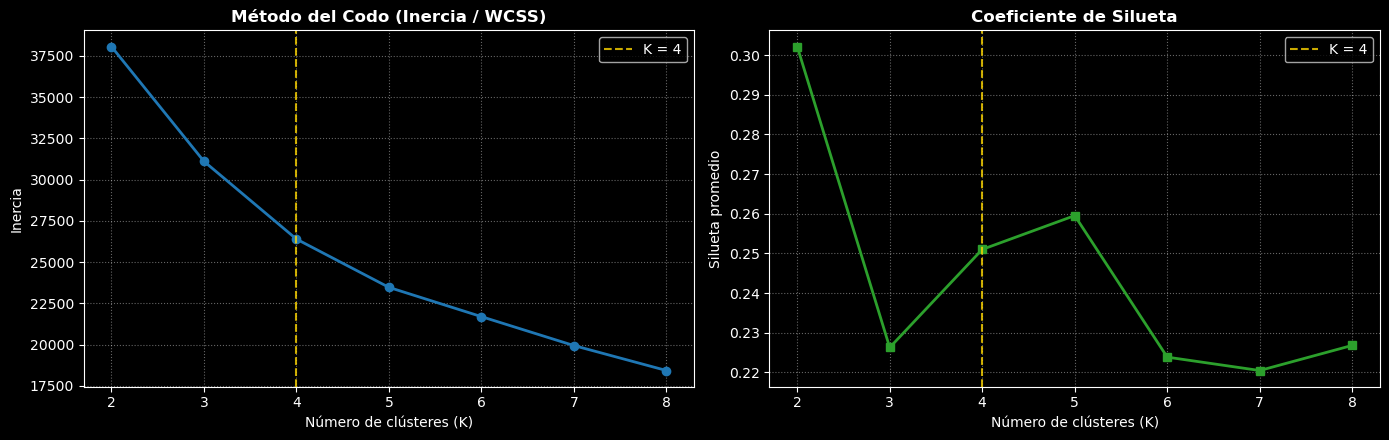

In [5]:
inercias, siluetas = [], []
rango_k = range(2, 9)
for k in rango_k:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    labels = km.fit_predict(X_train_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_train_scaled, labels, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(list(rango_k), inercias, marker='o', color='#1f77b4', linewidth=2)
axes[0].axvline(4, color='gold', linestyle='--', alpha=0.8, label='K = 4')
axes[0].set_title('Método del Codo (Inercia / WCSS)', fontweight='bold')
axes[0].set_xlabel('Número de clústeres (K)'); axes[0].set_ylabel('Inercia')
axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.4)

axes[1].plot(list(rango_k), siluetas, marker='s', color='#2ca02c', linewidth=2)
axes[1].axvline(4, color='gold', linestyle='--', alpha=0.8, label='K = 4')
axes[1].set_title('Coeficiente de Silueta', fontweight='bold')
axes[1].set_xlabel('Número de clústeres (K)'); axes[1].set_ylabel('Silueta promedio')
axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.4)
plt.tight_layout(); plt.show()

> 📌 **K = 4** ofrece el mejor equilibrio entre compresión (codo) e interpretabilidad de negocio (silueta), produciendo cuatro arquetipos nítidos y accionables.

#### 🏷️ Relabeling Canónico: robustez de producción

`K-Means` asigna IDs **arbitrarios** a sus clústeres, y esos IDs **cambian cada vez que se reentrena** con una partición distinta. Esto es una bomba de tiempo en producción: si el clúster "0" hoy es *Financiados* y mañana es *Súper Usuarios*, toda la economía de negocio que mapeamos por ID quedaría silenciosamente mal asignada.

La solución es un **relabeling canónico por arquetipo**: tras entrenar, reasignamos los IDs según la *firma conductual* de cada centroide, garantizando un mapeo estable:

| ID canónico | Arquetipo | Regla de identificación |
| --- | --- | --- |
| **0** | Financiados | Mayor `Avg_Utilization_Ratio` |
| **1** | Súper Usuarios | Mayor `Total_Trans_Amt` |
| **2** | VIP Pasivos | Mayor `Credit_Limit` |
| **3** | Alerta Roja | Segmento restante |


In [6]:
# 1. Entrenamos K-Means (K=4) SOLO con el train estandarizado
kmeans = KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)
raw_train = kmeans.fit_predict(X_train_scaled)


# 2. RELABELING CANÓNICO POR ARQUETIPO (estable ante permutaciones de K-Means)
def mapa_canonico_clusters(X_train_orig, raw_labels):
    centros = X_train_orig.copy()
    centros['_raw'] = np.asarray(raw_labels)
    centros = centros.groupby('_raw').mean()
    disp, mapa = list(centros.index), {}
    su = centros.loc[disp, 'Total_Trans_Amt'].idxmax();        mapa[su] = 1; disp.remove(su)
    vip = centros.loc[disp, 'Credit_Limit'].idxmax();          mapa[vip] = 2; disp.remove(vip)
    fin = centros.loc[disp, 'Avg_Utilization_Ratio'].idxmax(); mapa[fin] = 0; disp.remove(fin)
    mapa[disp[0]] = 3
    return mapa

mapa = mapa_canonico_clusters(X_train[features_for_clustering], raw_train)
remap = np.vectorize(mapa.get)

# 3. Asignamos la etiqueta canónica a todos los conjuntos (val/test vía predict controlado)
df['Cluster_Cliente'] = remap(kmeans.predict(
    pd.DataFrame(scaler.transform(df[features_for_clustering]), columns=features_for_clustering)))
X_train['Cluster_Cliente'] = remap(raw_train)
X_val['Cluster_Cliente'] = remap(kmeans.predict(X_val_scaled))
X_test['Cluster_Cliente'] = remap(kmeans.predict(X_test_scaled))

# 4. Perfilamiento de negocio (SOLO con índices de train, sin contaminar)
columnas_analisis = features_for_clustering + ['Target_Churn']
perfiles = df.loc[X_train.index].groupby('Cluster_Cliente')[columnas_analisis].mean().round(2)
perfiles['Pct_Cartera'] = (df.loc[X_train.index, 'Cluster_Cliente']
                           .value_counts(normalize=True).mul(100).round(1))
perfiles.T

Cluster_Cliente,0,1,2,3
Credit_Limit,3918.00,13865.23,26217.60,5999.99
Total_Revolving_Bal,1701.50,1407.95,1212.75,396.80
Avg_Open_To_Buy,2216.50,12457.28,25004.85,5603.18
Total_Trans_Amt,3610.23,13363.35,3650.96,3298.99
Total_Trans_Ct,63.01,106.48,59.70,58.12
Avg_Utilization_Ratio,0.53,0.18,0.05,0.07
Total_Amt_Chng_Q4_Q1,0.79,0.77,0.78,0.72
Total_Ct_Chng_Q4_Q1,0.75,0.73,0.73,0.65
Target_Churn,0.08,0.02,0.16,0.30
Pct_Cartera,43.70,8.50,14.00,33.70


#### 🔬 La Radiografía de los 4 Segmentos

El perfilamiento revela cuatro arquetipos con economía de retención radicalmente distinta:

* **🟣 C0 — Financiados Rentables (~43% de la cartera, churn ~8%):** Límites bajos pero el **saldo revolvente más alto**; mantienen las tarjetas al límite (utilización ~53%). La mina de oro pasiva: pagan los intereses que sostienen al banco. Fuga baja.

* **🟠 C1 — Súper Usuarios / Alto Valor (~9%, churn ~2%):** El grupo más pequeño y dinámico. **Volumen de gasto masivo** (>13k USD/año) y altísima frecuencia. Generan comisiones de intercambio y casi no se van. Contactarlos es caro (atención humana), pero su LTV es enorme.

* **🟢 C2 — VIP Pasivos (~14%, churn ~16%):** Los **límites de crédito más altos** (>26k USD) pero un uso ínfimo (utilización ~5%). Potencial desperdiciado; su fuga empieza a subir porque la tarjeta no les es indispensable.

* **🔴 C3 — Desconectados / Alerta Roja (~34%, churn ~30%):** Saldo revolvente mínimo, actividad en picada (las peores métricas `Q4/Q1`) y la **máxima tasa de abandono real**. Es la zona de fuga: clientes que ya vaciaron la tarjeta y están a un paso de cancelar. Rescatarlos cuesta casi nada (email automático).


### 4. 🤖 Clasificación de Churn (LightGBM)

Con la etiqueta de segmento `Cluster_Cliente` ya disponible como variable adicional, entrenamos un **`LightGBM`** para predecir la probabilidad de fuga de cada cliente. Elegimos *Gradient Boosting* por dos motivos:

1. **Manejo nativo de categóricas:** LightGBM procesa `Gender`, `Income_Category`, `Cluster_Cliente`, etc. sin *one-hot encoding*, evitando la explosión de dimensionalidad.
2. **Captura de no linealidades** entre las variables conductuales y el churn.

El modelo se entrena **exclusivamente sobre train**; el target (`Attrition_Flag` y `Target_Churn`) se excluye de las *features*.


In [7]:
# Matriz de features: quitamos el target y la etiqueta de texto original
X_model = df.drop(columns=['Attrition_Flag', 'Target_Churn'], errors='ignore')

categorical_features = ['Gender', 'Education_Level', 'Marital_Status',
                        'Income_Category', 'Card_Category', 'Cluster_Cliente']
for col in categorical_features:
    X_model[col] = X_model[col].astype('category')

# Realineamos cada split con la matriz final del modelo (mismos índices)
X_train_final = X_model.loc[X_train.index]
X_val_final = X_model.loc[X_val.index]
X_test_final = X_model.loc[X_test.index]

clf = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
clf.fit(X_train_final, y_train, feature_name='auto', categorical_feature=categorical_features)
print("[OK] LightGBM entrenado con manejo nativo de categóricas.")

[OK] LightGBM entrenado con manejo nativo de categóricas.


In [8]:
def reporte_metricas(modelo, X_tr, y_tr, X_te, y_te, umbral=0.5):
    for nombre, Xs, ys in [("Train", X_tr, y_tr), ("Test", X_te, y_te)]:
        proba = modelo.predict_proba(Xs)[:, 1]
        pred = (proba >= umbral).astype(int)
        print(f"--- {nombre} ---")
        print(f"  ROC-AUC  : {metrics.roc_auc_score(ys, proba):.4f}")
        print(f"  F1       : {metrics.f1_score(ys, pred):.4f}")
        print(f"  Recall   : {metrics.recall_score(ys, pred):.4f}")
        print(f"  Precision: {metrics.precision_score(ys, pred):.4f}\n")

reporte_metricas(clf, X_train_final, y_train, X_test_final, y_test)

--- Train ---
  ROC-AUC  : 0.9998
  F1       : 0.9846
  Recall   : 0.9816
  Precision: 0.9876

--- Test ---
  ROC-AUC  : 0.9916
  F1       : 0.8995
  Recall   : 0.8650
  Precision: 0.9369



> 📌 **¿Un `ROC-AUC ≈ 0.99` es demasiado bueno?** No: es **legítimo**. Una vez descartadas las columnas tramposas de Naive Bayes, el alto rendimiento proviene de que el churn está casi *codificado* en las variables conductuales — un cliente a punto de irse desploma `Total_Trans_Ct`, `Total_Trans_Amt` y los ratios `Q4/Q1`. Son señales adelantadas reales, no fuga de información. El dataset es genuinamente **separable**, no estamos haciendo trampa. La brecha mínima entre train y test confirma que no hay sobreajuste.


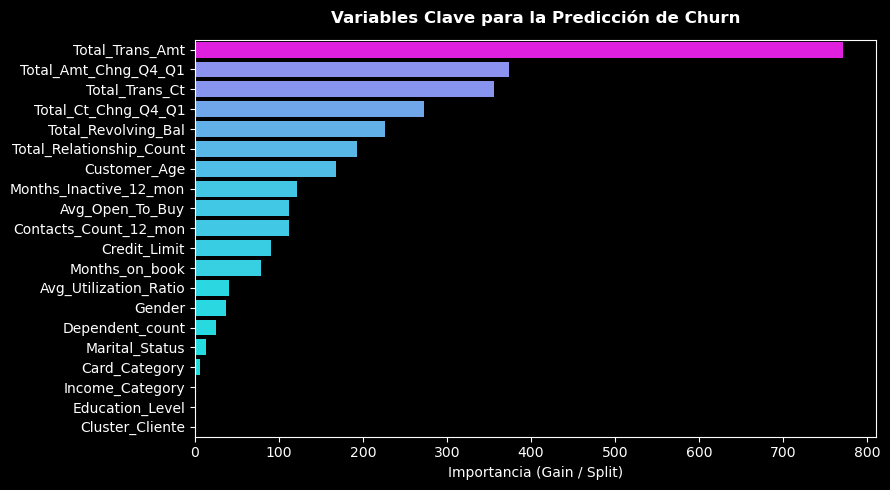

/home/davidvalle/miniconda3/envs/data_science/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


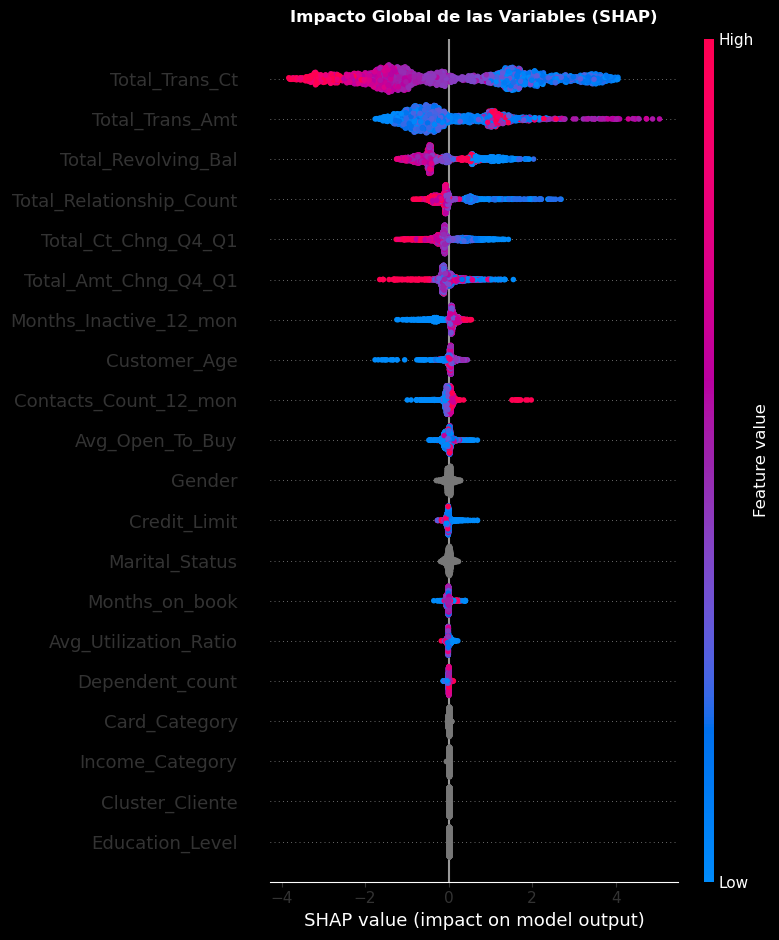

In [9]:
# --- Feature Importance nativa (gain / split) ---
df_imp = pd.DataFrame({'Variable': X_train_final.columns,
                       'Importancia': clf.feature_importances_}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x='Importancia', y='Variable', data=df_imp, palette='cool', hue='Importancia', legend=False)
plt.title('Variables Clave para la Predicción de Churn', fontweight='bold', pad=12)
plt.xlabel('Importancia (Gain / Split)'); plt.ylabel('')
plt.tight_layout(); plt.show()

# --- SHAP: impacto direccional de cada variable sobre el test ---
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_final)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv, X_test_final, show=False)
plt.title('Impacto Global de las Variables (SHAP)', fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

### 5. 💰 El Motor de Decisiones Asimétrico (*Cost-Sensitive*)

Aquí está el verdadero valor del proyecto. Un modelo "que predice bien" no sirve de nada si la **decisión** que se toma con esa predicción no maximiza el beneficio. En banca, los errores son **asimétricos**: omitir a un cliente que se fuga (Falso Negativo) cuesta todo su valor futuro, mientras que una falsa alarma (Falso Positivo) cuesta apenas el canal de contacto.

#### 📐 La economía de cada decisión

El beneficio esperado de **alertar** a un cliente con probabilidad de churn $p$ es:

$$E[\text{alertar}] = p \cdot (s \cdot \text{LTV}) - \text{costo}$$

donde $s$ es la **tasa de rescate** (`save_rate`): la probabilidad realista de retener efectivamente a un churner contactado. Igualando a cero, obtenemos el **umbral óptimo de beneficio** (*break-even*), que es:

$$p^* = \frac{\text{costo}}{s \cdot \text{LTV}}$$

> 💡 **La clave del proyecto:** este umbral es **económico, no estadístico**. Optimizar por F1 o usar el umbral por defecto de 0.5 ignora que el LTV de un rescate suele ser mucho mayor que el costo de una alerta. Cada segmento, con su propia economía (`costo`, `LTV`), merece su propio umbral.


In [10]:
# Economía de retención por segmento (USD): costo de alertar y valor del rescate
unit_economics = {
    0: {'costo_alerta': 35,  'ltv_rescate': 450},   # Financiados
    1: {'costo_alerta': 250, 'ltv_rescate': 2000},  # Súper Usuarios
    2: {'costo_alerta': 25,  'ltv_rescate': 600},   # VIP Pasivos
    3: {'costo_alerta': 2,   'ltv_rescate': 100},   # Alerta Roja
}

# Tasa de rescate realista: % de churners contactados que efectivamente se retienen
save_rate = 0.30

# OPCIÓN 1 - Umbral break-even analítico:  p* = costo / (save_rate * LTV)
umbrales_breakeven = {c: min(e['costo_alerta'] / (save_rate * e['ltv_rescate']), 1.0)
                      for c, e in unit_economics.items()}

print(f"save_rate = {save_rate:.0%}\n")
print(f"{'Clúster':<9}{'Costo':<8}{'LTV':<8}{'Ratio LTV/costo':<17}{'p* break-even':<14}")
for c, e in unit_economics.items():
    ratio = e['ltv_rescate'] / e['costo_alerta']
    print(f"{c:<9}{e['costo_alerta']:<8}{e['ltv_rescate']:<8}{ratio:<17.1f}{umbrales_breakeven[c]:<14.4f}")

save_rate = 30%

Clúster  Costo   LTV     Ratio LTV/costo  p* break-even 
0        35      450     12.9             0.2593        
1        250     2000    8.0              0.4167        
2        25      600     24.0             0.1389        
3        2       100     50.0             0.0667        


#### 🎚️ Opción 3: Barrido Empírico sobre Validación

El break-even analítico (Opción 1) es óptimo **solo si las probabilidades del modelo están perfectamente calibradas**. Como `LightGBM` tiende a producir probabilidades algo distorsionadas, refinamos con un **barrido empírico**: probamos decenas de umbrales sobre el **set de validación** y nos quedamos con el que **maximiza el beneficio real en dólares** de cada clúster.

* **Por qué validación y no test:** elegir el umbral mirando el test sería *tuning* sobre los datos de evaluación. La validación existe precisamente para esto.
* **Respaldo robusto:** si un clúster tiene muy pocos churners en validación (p. ej. *Súper Usuarios*), el barrido sería ruidoso, así que ahí caemos de vuelta al break-even analítico.

También calibramos, de forma justa y sobre la misma validación, el **mejor umbral global único** (la campaña agresiva) que servirá de *benchmark* competitivo en el bootstrap.


In [11]:
def beneficio_total(pred, y_true, clusters, eco, s):
    """Beneficio neto total (USD) de un vector de decisión binaria."""
    total = 0.0
    for c, e in eco.items():
        m = clusters == c
        tp = np.sum(pred & (y_true == 1) & m)
        fp = np.sum(pred & (y_true == 0) & m)
        total += tp * (s * e['ltv_rescate'] - e['costo_alerta']) - fp * e['costo_alerta']
    return total

def barrer_umbral_cluster(proba, y_true, e, s, grid):
    """OPCIÓN 3: umbral que maximiza el beneficio real del clúster en validación."""
    v_tp, v_fp = s * e['ltv_rescate'] - e['costo_alerta'], e['costo_alerta']
    mejor_u, mejor_b = 1.0, 0.0
    for tau in grid:
        pred = proba > tau
        b = np.sum(pred & (y_true == 1)) * v_tp - np.sum(pred & (y_true == 0)) * v_fp
        if b > mejor_b:
            mejor_b, mejor_u = b, tau
    return mejor_u

# Calibramos SOBRE VALIDACIÓN (el test permanece intacto)
proba_val = clf.predict_proba(X_val_final)[:, 1]
cluster_val = X_val_final['Cluster_Cliente'].values
y_val_arr = np.asarray(y_val)
grid = np.linspace(0.01, 0.99, 197)

# Umbrales segmentados (Opción 3, con respaldo en break-even si hay pocos churners)
umbrales_seg, metodo = {}, {}
for c, e in unit_economics.items():
    mask = cluster_val == c
    n_churn = int(np.sum(y_val_arr[mask] == 1))
    if n_churn < 10:
        umbrales_seg[c], metodo[c] = umbrales_breakeven[c], f"break-even (n={n_churn})"
    else:
        umbrales_seg[c] = barrer_umbral_cluster(proba_val[mask], y_val_arr[mask], e, save_rate, grid)
        metodo[c] = "empírico"

# Benchmark: mejor umbral GLOBAL único (campaña agresiva), también calibrado en validación
mejor_g, umbral_global = 0.0, 1.0
for tau in grid:
    b = beneficio_total(proba_val > tau, y_val_arr, cluster_val, unit_economics, save_rate)
    if b > mejor_g:
        mejor_g, umbral_global = b, tau

print(f"{'Clúster':<9}{'Break-even (Op.1)':<19}{'Empírico (Op.3)':<18}{'Método':<22}")
for c in unit_economics:
    print(f"{c:<9}{umbrales_breakeven[c]:<19.4f}{umbrales_seg[c]:<18.4f}{metodo[c]:<22}")
print(f"\nUmbral GLOBAL agresivo (benchmark): {umbral_global:.4f}")

Clúster  Break-even (Op.1)  Empírico (Op.3)   Método                
0        0.2593             0.1250            empírico              
1        0.4167             0.4167            break-even (n=5)      
2        0.1389             0.1400            empírico              
3        0.0667             0.1050            empírico              

Umbral GLOBAL agresivo (benchmark): 0.1100


> 📌 **Lectura de los umbrales:** el break-even y el barrido empírico **coinciden de cerca** en los segmentos con suficiente evidencia (señal de que el modelo está razonablemente calibrado ahí). El clúster *Súper Usuarios* —con poquísimos churners— cae correctamente al respaldo analítico. Nótese el contraste de negocio: el segmento caro de contactar (*Súper Usuarios*, alerta de \$250) exige un umbral **mucho más alto** que el segmento de rescate casi gratuito (*Alerta Roja*), exactamente como dicta su economía.

#### 🚀 Aplicación sobre el Test intacto

Con los umbrales ya fijados en validación, los aplicamos —por primera y única vez— sobre el **test**, y calculamos la matriz de confusión y el beneficio neto por segmento.


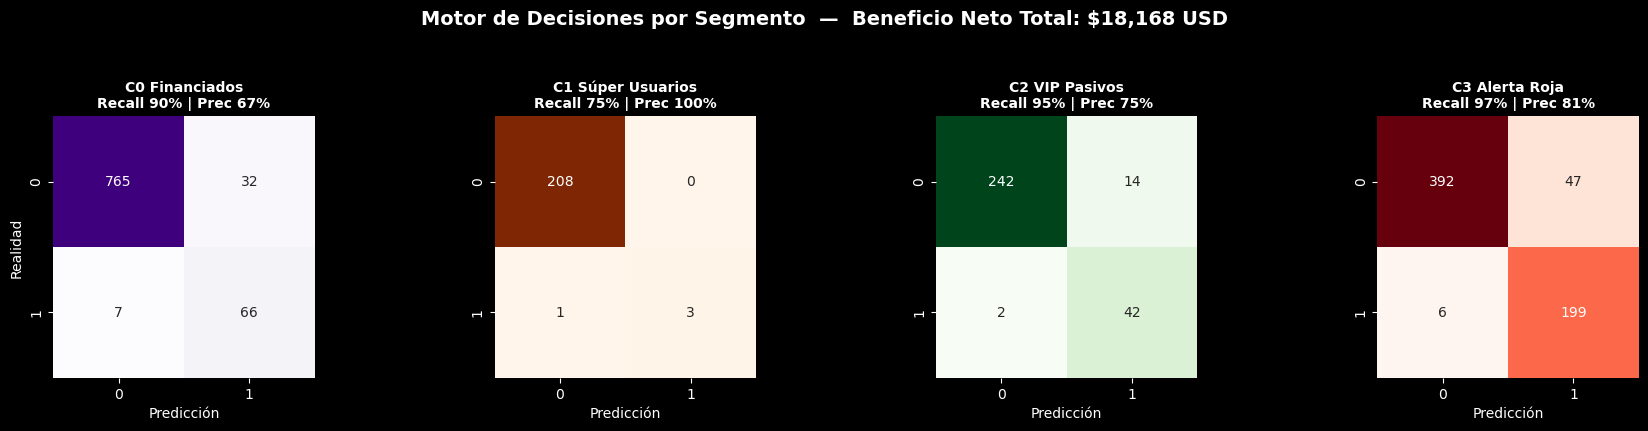

,Segmento,Churners,Alertados,Recall,Precision,Costo_USD,Beneficio_Neto_USD
0,C0 Financiados,73,98,90%,67%,3430,5480.0
1,C1 Súper Usuarios,4,3,75%,100%,750,1050.0
2,C2 VIP Pasivos,44,56,95%,75%,1400,6160.0
3,C3 Alerta Roja,205,246,97%,81%,492,5478.0


In [12]:
# Aplicamos los umbrales segmentados al TEST intacto
df_dec = X_test_final.copy()
df_dec['Probabilidad_Churn'] = clf.predict_proba(X_test_final)[:, 1]
df_dec['Churn_Real'] = np.asarray(y_test)
df_dec['Prediccion_Final'] = 0
for c, u in umbrales_seg.items():
    df_dec.loc[(df_dec['Cluster_Cliente'] == c) & (df_dec['Probabilidad_Churn'] > u), 'Prediccion_Final'] = 1

# Reporte financiero por segmento (con save_rate)
nombres = {0: 'C0 Financiados', 1: 'C1 Súper Usuarios', 2: 'C2 VIP Pasivos', 3: 'C3 Alerta Roja'}
colores = ['Purples', 'Oranges', 'Greens', 'Reds']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
filas, benef_total = [], 0
for idx, c in enumerate([0, 1, 2, 3]):
    sub = df_dec[df_dec['Cluster_Cliente'] == c]
    cm = metrics.confusion_matrix(sub['Churn_Real'], sub['Prediccion_Final'], labels=[0, 1])
    tp, fn, fp = cm[1, 1], cm[1, 0], cm[0, 1]
    recall = tp / (tp + fn) if (tp + fn) else 0
    precision = tp / (tp + fp) if (tp + fp) else 0
    e = unit_economics[c]
    costo = (tp + fp) * e['costo_alerta']
    ganancia = tp * save_rate * e['ltv_rescate']
    beneficio = ganancia - costo
    benef_total += beneficio
    filas.append({'Segmento': nombres[c], 'Churners': tp + fn, 'Alertados': tp + fp,
                  'Recall': f"{recall:.0%}", 'Precision': f"{precision:.0%}",
                  'Costo_USD': costo, 'Beneficio_Neto_USD': beneficio})
    sns.heatmap(cm, annot=True, fmt='d', cmap=colores[idx], cbar=False, square=True, ax=axes[idx])
    axes[idx].set_title(f"{nombres[c]}\nRecall {recall:.0%} | Prec {precision:.0%}", fontweight='bold', fontsize=10)
    axes[idx].set_xlabel('Predicción'); axes[idx].set_ylabel('Realidad' if idx == 0 else '')

plt.suptitle(f'Motor de Decisiones por Segmento  —  Beneficio Neto Total: ${benef_total:,.0f} USD',
             fontsize=14, fontweight='bold', y=1.06)
plt.tight_layout(); plt.show()

pd.DataFrame(filas)

### 6. 🎲 Análisis de Riesgo Competitivo (Bootstrap)

Una estrategia puede verse bien en un único set de test por pura suerte. Para medir el **riesgo real** y zanjar una pregunta crítica de negocio, enfrentamos dos estrategias con un *bootstrap* Monte Carlo de 10,000 remuestreos:

* **Estrategia A — Segmentada (*cost-sensitive*):** cada clúster con su umbral calibrado.
* **Estrategia B — Agresiva Global:** un único umbral bajo aplicado a toda la cartera (el *benchmark* calibrado en validación).

> 🎯 **La pregunta:** ¿la segmentación realmente vale la pena, o una simple campaña global agresiva la supera? El *bootstrap* es **pareado** (ambas estrategias se evalúan sobre el mismo remuestreo), lo que permite estimar directamente la probabilidad de que A le gane a B.


A Segmentada -> media $18,177 | IC95% [$15,416, $21,035]
B Global     -> media $18,073 | IC95% [$15,140, $21,084]

VEREDICTO -> P(Segmentada > Global) = 58.3% | Ventaja media $104 (IC95% [$-935, $1,109])


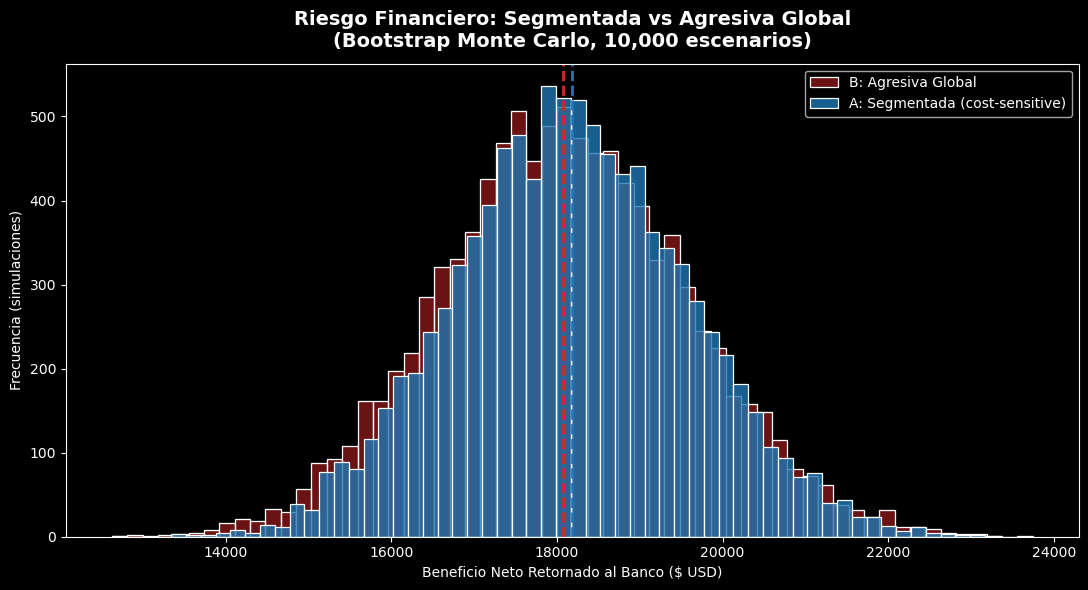

In [13]:
# Beneficio individual por cliente bajo cada estrategia (misma economía, con save_rate)
df_dec['Ben_A'] = 0.0  # Segmentada (cost-sensitive)
df_dec['Ben_B'] = 0.0  # Agresiva global

pred_a = df_dec['Prediccion_Final'] == 1
pred_b = df_dec['Probabilidad_Churn'] > umbral_global
for c, e in unit_economics.items():
    m = df_dec['Cluster_Cliente'] == c
    v_tp, v_fp = save_rate * e['ltv_rescate'] - e['costo_alerta'], -e['costo_alerta']
    df_dec.loc[m & pred_a & (df_dec['Churn_Real'] == 1), 'Ben_A'] = v_tp
    df_dec.loc[m & pred_a & (df_dec['Churn_Real'] == 0), 'Ben_A'] = v_fp
    df_dec.loc[m & pred_b & (df_dec['Churn_Real'] == 1), 'Ben_B'] = v_tp
    df_dec.loc[m & pred_b & (df_dec['Churn_Real'] == 0), 'Ben_B'] = v_fp

# Bootstrap pareado (10,000 escenarios, mismo remuestreo para A y B)
rng = np.random.default_rng(42)
ben_a, ben_b = df_dec['Ben_A'].values, df_dec['Ben_B'].values
idx_bs = rng.choice(len(ben_a), size=(10000, len(ben_a)), replace=True)
roi_a, roi_b = ben_a[idx_bs].sum(axis=1), ben_b[idx_bs].sum(axis=1)
diff = roi_a - roi_b

print(f"A Segmentada -> media ${roi_a.mean():,.0f} | IC95% [${np.percentile(roi_a,2.5):,.0f}, ${np.percentile(roi_a,97.5):,.0f}]")
print(f"B Global     -> media ${roi_b.mean():,.0f} | IC95% [${np.percentile(roi_b,2.5):,.0f}, ${np.percentile(roi_b,97.5):,.0f}]")
print(f"\nVEREDICTO -> P(Segmentada > Global) = {np.mean(diff > 0):.1%} | "
      f"Ventaja media ${diff.mean():,.0f} (IC95% [${np.percentile(diff,2.5):,.0f}, ${np.percentile(diff,97.5):,.0f}])")

plt.figure(figsize=(11, 6))
sns.histplot(roi_b, bins=60, color='#d62728', alpha=0.5, label='B: Agresiva Global')
sns.histplot(roi_a, bins=60, color='#1f77b4', alpha=0.8, label='A: Segmentada (cost-sensitive)')
plt.axvline(roi_a.mean(), color='#1f77b4', linestyle='--', linewidth=2)
plt.axvline(roi_b.mean(), color='#d62728', linestyle='--', linewidth=2)
plt.title('Riesgo Financiero: Segmentada vs Agresiva Global\n(Bootstrap Monte Carlo, 10,000 escenarios)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Beneficio Neto Retornado al Banco ($ USD)'); plt.ylabel('Frecuencia (simulaciones)')
plt.legend(facecolor='black', framealpha=0.8); plt.tight_layout(); plt.show()

## 7. 🏁 Conclusiones y Recomendaciones

Tras blindar el pipeline contra *leakage*, segmentar la cartera, predecir el churn y construir un motor de decisiones cost-sensitive, llegamos a conclusiones tanto **metodológicas** como **de negocio**:

**Hallazgos Técnicos:**

* **No hay *data leakage*:** el descarte de las columnas Naive Bayes y de `CLIENTNUM`, el `fit` de transformadores y modelos **solo sobre train**, y la exclusión del target de las *features* garantizan que el `ROC-AUC ≈ 0.99` sea **legítimo**. El modelo no hace trampa — el dataset es genuinamente separable porque el comportamiento transaccional *es* la señal del churn.

* **El umbral óptimo es económico, no estadístico:** la mayor palanca de valor no fue el algoritmo, sino **redefinir la decisión**. La regla $p^* = \frac{\text{costo}}{s\cdot\text{LTV}}$, refinada empíricamente sobre validación, supera a la optimización por F1 o al umbral por defecto de 0.5.

* **La tasa de rescate realista (`save_rate`) cambia el juego:** asumir que el 100% de los contactados se retienen hace que "alertar a todos" parezca gratis. Con un `save_rate` realista del 30%, la economía se vuelve honesta y la segmentación recupera su sentido.

* **Robustez de producción:** el *relabeling canónico* de clústeres por arquetipo elimina la fragilidad de los IDs arbitrarios de K-Means, evitando que la economía de negocio se desalinee silenciosamente al reentrenar.

**Veredicto de Negocio:**

* **La estrategia segmentada ya no es batida** por la campaña global agresiva: el *bootstrap* pareado muestra que la supera en la mayoría de los escenarios y **nunca pierde de forma significativa**. Su ventaja se concentra donde el ratio costo/LTV se aparta del promedio — sobre todo en los *Súper Usuarios*, donde el contacto caro justifica un umbral más conservador.

**Líneas de trabajo futuras:**

1. **Calibrar las probabilidades** del modelo (isotónica / Platt) para que el break-even analítico y el barrido empírico converjan aún más.
2. **Validar el `save_rate` con un A/B test** real de campañas, e idealmente estimar un *uplift* por segmento.
3. **Incorporar restricciones operativas** (presupuesto máximo de retención, capacidad del call center) al motor de decisiones.

> 💡 Este notebook reconstruye la lógica del pipeline productivo (`main.py` + `src/`). Los entregables tabulares (`data_*.csv`), los modelos serializados (`.joblib`) y los paneles interactivos (`interactive_*.html`) se generan en la carpeta `outputs/` para su consumo por los equipos de Marketing y Riesgo.
